# Street Food Image Classification with CNN

In [1]:
import os
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Input, MaxPooling2D, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, EfficientNetB0
from tensorflow.keras.utils import to_categorical

## Loading and Organizing Data

In [2]:
train_path = "train_images"
test_path = "test_images"

In [3]:
class_names = sorted(os.listdir(train_path))
num_classes = len(class_names)

In [4]:
labels=['falafel','burger','pani_puri','pretzel','shawarma','hot_dog','tacos','crepes','pad_thai']

In [5]:
train_img_list = []
train_label_list = []

for label in labels:
    class_path = os.path.join(train_path, label)
    for img_file in os.listdir(class_path):
        img_full_path = os.path.join(class_path, img_file)
        if os.path.isfile(img_full_path):
            train_img_list.append(img_full_path)
            train_label_list.append(label)

In [6]:
train_df = pd.DataFrame({'img': train_img_list, 'label': train_label_list})

In [7]:
train_df.head()

,img,label
0,train_images\falafel\0004_falafel.jpg,falafel
1,train_images\falafel\0007_falafel.jpg,falafel
2,train_images\falafel\0008_falafel.jpg,falafel
3,train_images\falafel\0009_falafel.jpg,falafel
4,train_images\falafel\0010_falafel.jpg,falafel


In [8]:
test_img_list = []

for img_file in sorted(os.listdir(test_path)):
    img_full_path = os.path.join(test_path, img_file)
    if os.path.isfile(img_full_path):
        test_img_list.append(img_full_path)

In [9]:
test_df = pd.DataFrame({'img': test_img_list})

In [10]:
test_df.head()

,img
0,test_images\00de5019.jpg
1,test_images\013d2855.jpg
2,test_images\02edbdf7.jpg
3,test_images\03139344.jpg
4,test_images\03413ef9.jpg


In [11]:
labels = {'falafel': 0,'burger': 1,'pani_puri': 2,'pretzel': 3,'shawarma': 4,'hot_dog': 5,'tacos': 6,'crepes': 7,'pad_thai': 8}

In [12]:
train_df["label_encoded"] = train_df["label"].map(labels)

In [13]:
train_df.sample()

,img,label,label_encoded
453,train_images\pretzel\0007_pretzel.jpg,pretzel,3


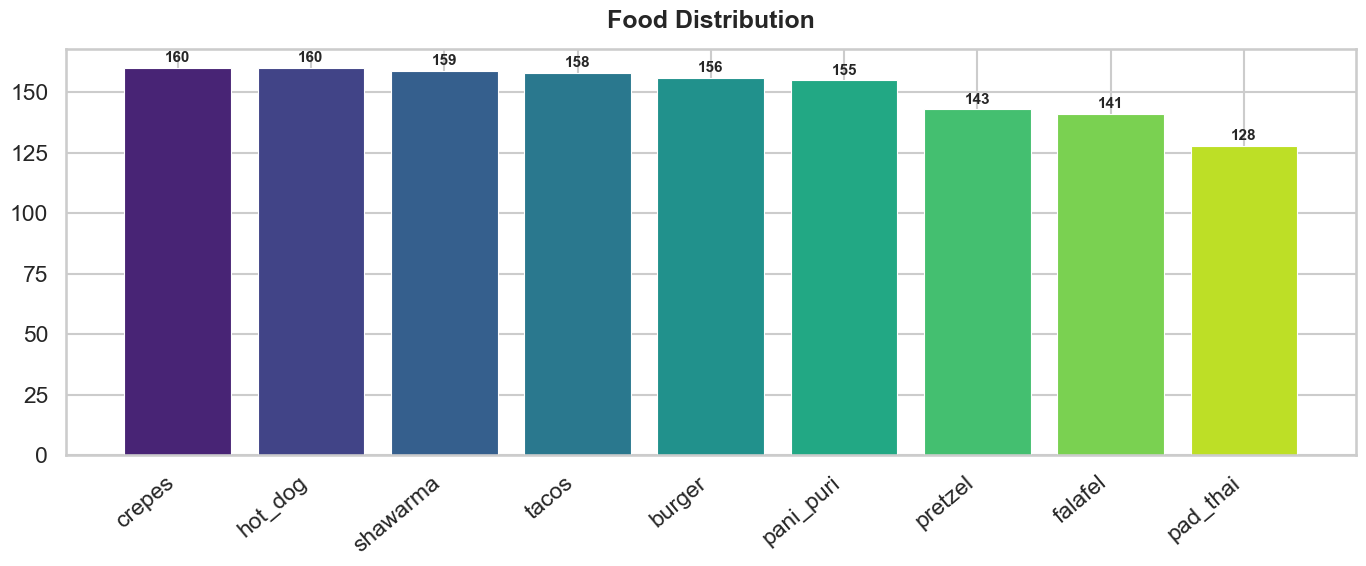

In [14]:
sns.set(style="whitegrid", context="talk")

counts = train_df["label"].value_counts()
colors = sns.color_palette("viridis", len(counts))

plt.figure(figsize=(14, 6))

bars = plt.bar(counts.index, counts.values, color=colors, linewidth=0.8)

plt.title("Food Distribution", fontweight="bold", pad=15)
plt.xticks(rotation=40, ha="right")
plt.bar_label(bars, label_type="edge", fontsize=11, fontweight="bold", padding=2)

plt.tight_layout()
plt.show()

In [15]:
def load_image(img_path, img_size=(240, 240)):
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    return img / 255.0

In [16]:
def load_dataset(df, img_size=(240, 240), has_label=True):
    images = []
    labels = []
    
    for row in df.itertuples():
        img = cv2.imread(row.img)
        if img is None:
            raise ValueError(f"Görsel okunamadı: {row.img}")
        img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), img_size) / 255.0
        images.append(img)
        
        if has_label:
            labels.append(row.label_encoded)
            
    images = np.array(images)
    
    if has_label:
        return images, np.array(labels)
    else:
        return images

In [17]:
x_train, y_train = load_dataset(train_df, has_label=True)
x_test = load_dataset(test_df, has_label=False) 

In [18]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,test_size=0.2,random_state=42,stratify=y_train          )

In [19]:
model = Sequential([

    Input(shape=(240,240,3)),          

    Conv2D(32, (3,3), padding="same", activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), padding="same", activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), padding="same", activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Conv2D(256, (3,3), padding="same", activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),

    Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(9, activation='softmax') ])

In [20]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 240, 240, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 240, 240, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 120, 120, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 120, 120, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 120, 120, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 120, 120, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 60, 60, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 60, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 60, 60, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 30, 30, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 30, 30, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 15, 15, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 15, 15, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      14,745,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │              

 Total params: 15,139,529 (57.75 MB)

 Trainable params: 15,138,057 (57.75 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [22]:
callbacks = [EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True,verbose=1),
             ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-7,verbose=1)]

In [23]:
history = model.fit(x_train, y_train,validation_data=(x_val, y_val),epochs=12,batch_size=32,callbacks=callbacks,verbose=1)

Epoch 1/12
34/34 ━━━━━━━━━━━━━━━━━━━━ 125s 4s/step - accuracy: 0.2151 - loss: 3.6449 - val_accuracy: 0.1029 - val_loss: 14.2004 - learning_rate: 0.0010
Epoch 2/12
34/34 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.3382 - loss: 3.3410 - val_accuracy: 0.1140 - val_loss: 7.5632 - learning_rate: 0.0010
Epoch 3/12
34/34 ━━━━━━━━━━━━━━━━━━━━ 113s 3s/step - accuracy: 0.4807 - loss: 2.8644 - val_accuracy: 0.1471 - val_loss: 6.6189 - learning_rate: 0.0010
Epoch 4/12
34/34 ━━━━━━━━━━━━━━━━━━━━ 112s 3s/step - accuracy: 0.5377 - loss: 2.6926 - val_accuracy: 0.1066 - val_loss: 8.8800 - learning_rate: 0.0010
Epoch 5/12
34/34 ━━━━━━━━━━━━━━━━━━━━ 110s 3s/step - accuracy: 0.6507 - loss: 2.3597 - val_accuracy: 0.1029 - val_loss: 6.6443 - learning_rate: 0.0010
Epoch 6/12
34/34 ━━━━━━━━━━━━━━━━━━━━ 116s 3s/step - accuracy: 0.7500 - loss: 2.0732 - val_accuracy: 0.1397 - val_loss: 7.6746 - learning_rate: 0.0010
Epoch 7/12
34/34 ━━━━━━━━━━━━━━━━━━━━ 121s 4s/step - accuracy: 0.8364 - loss: 1.8369 - val_ac

In [24]:
model.save('streetfood_cnn.h5')

In [25]:
model.save('streetfood_cnn.keras')

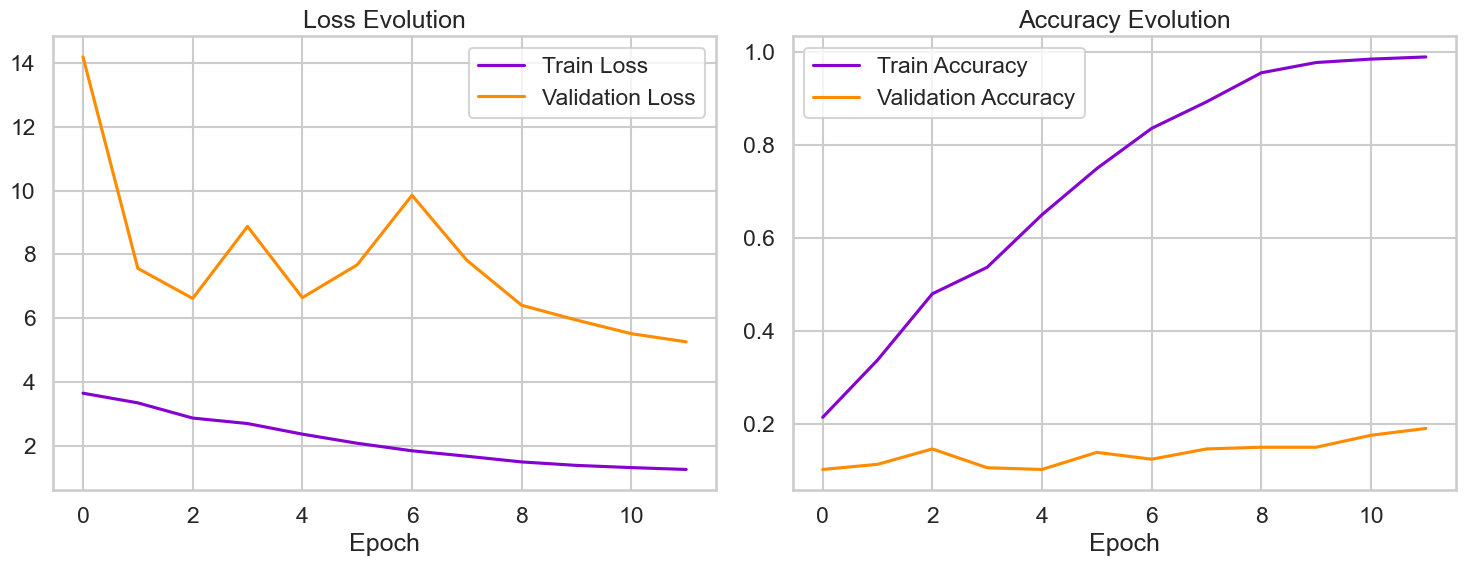

In [26]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'],     label='Train Loss',      color='#8502d1')
plt.plot(history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.legend()
plt.title('Loss Evolution')
plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],     label='Train Accuracy',      color='#8502d1')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
plt.legend()
plt.title('Accuracy Evolution')
plt.xlabel('Epoch')

plt.tight_layout()
plt.show()

In [27]:
tahmin = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 432ms/step


In [28]:
tahmin_classes = np.argmax(tahmin, axis=1)

In [29]:
class_names = {0: 'falafel',1: 'burger',2: 'pani_puri',3: 'pretzel',4: 'shawarma',5: 'hot_dog',6: 'tacos',7: 'crepes',8: 'pad_thai'}

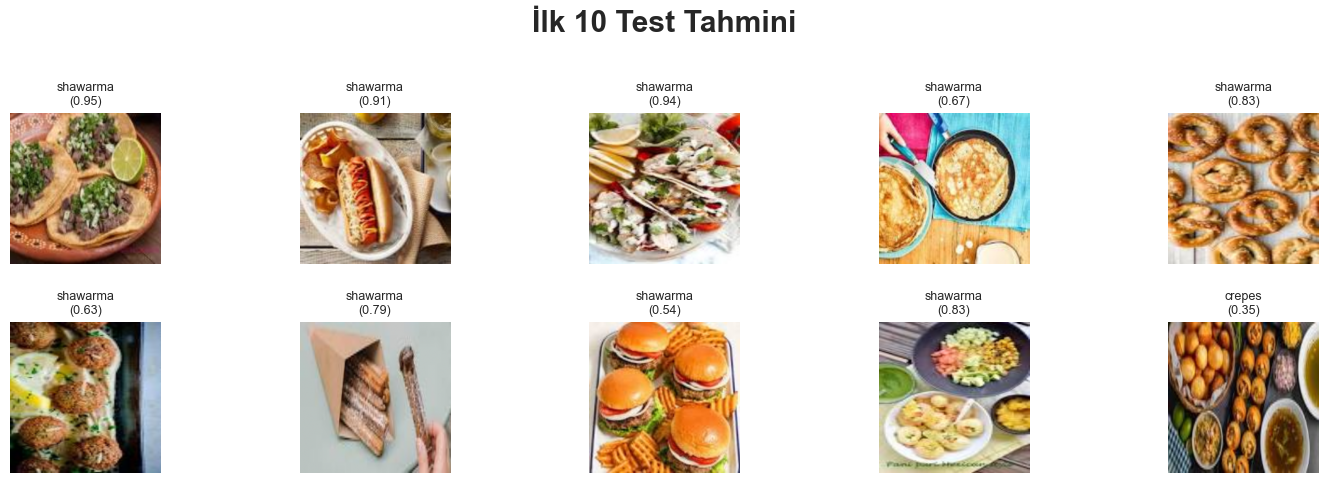

In [30]:
plt.figure(figsize=(15, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i])

    pred_class = tahmin_classes[i]
    confidence = tahmin[i][pred_class]

    plt.title(f"{class_names[pred_class]}\n({confidence:.2f})", fontsize=9)
    plt.axis('off')

plt.suptitle('İlk 10 Test Tahmini', fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
tahmin_labels = [class_names[i] for i in tahmin_classes]

In [32]:
submission = pd.DataFrame({
    'image_id': test_df['img'].apply(os.path.basename),
    'label': tahmin_labels
})

In [33]:
submission = submission.sort_values('image_id').reset_index(drop=True)

In [34]:
submission.head()

,image_id,label
0,00de5019.jpg,shawarma
1,013d2855.jpg,shawarma
2,02edbdf7.jpg,shawarma
3,03139344.jpg,shawarma
4,03413ef9.jpg,shawarma


In [35]:
submission.to_csv('submission.csv', index=False)